# 03a — CNN from Scratch · Alertreck Threat Detection

**Model:** 4-block CNN trained on 128-bin log-mel spectrograms  
**Classes:** 7 fine-grained (background_animals, background_wind_rain, threat_chainsaw, threat_dog, threat_gunshot, threat_human, threat_vehicle)  
**Data:** `data/processed/mel/` shards from Stage 2 preprocessing  
**Platform:** Local (alertreck conda env) — or Kaggle with GPU

---

## Local Setup

Run from the repo root with the alertreck conda env:
```bash
conda activate alertreck
conda install -n alertreck -c conda-forge pytorch torchvision seaborn -y
jupyter notebook notebooks/03a-train-cnn.ipynb
```

In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import seaborn as sns

print(f'PyTorch  {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   {device}')
if device.type == 'cuda':
    print(f'GPU      {torch.cuda.get_device_name(0)}')
    print(f'VRAM     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  2.10.0+cu128
Device   cuda
GPU      Tesla T4
VRAM     15.6 GB


In [ ]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
CFG = {
    # paths — relative to notebooks/ directory
    'data_root':   Path('../data/processed/mel'),
    'output_dir':  Path('../models/custom_cnn'),

    # model
    'n_classes':   7,
    'in_channels': 1,

    # spectrogram shape from Stage 2 (win=1102, hop=441, SR=44100)
    # frames = 1 + floor(132300 / 441) = 300
    'n_mels':      128,
    'n_frames':    300,

    # training
    'seed':        42,
    'epochs':      40,
    'batch_size':  128,
    'lr':          1e-3,
    'weight_decay':1e-4,
    'patience':    7,        # early stopping patience
    'lr_patience': 3,        # ReduceLROnPlateau patience
    'lr_factor':   0.5,

    # curriculum phase epoch boundaries (A → B → C)
    # first 15 epochs: clean + aug_A
    # next 10 epochs:  clean + aug_B
    # remaining:       clean + aug_C
    'phase_epochs': {'A': 15, 'B': 10, 'C': 999},

    # labels (must match class_labels_indices.csv order)
    'label_names': [
        'background_animals',
        'background_wind_rain',
        'threat_chainsaw',
        'threat_dog',
        'threat_gunshot',
        'threat_human',
        'threat_vehicle',
    ],
}

CFG['output_dir'].mkdir(parents=True, exist_ok=True)

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if device.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print('Config OK')
print(f"Data root : {CFG['data_root'].resolve()}")
print(f"Output    : {CFG['output_dir'].resolve()}")
print(f"Mel shape : ({CFG['n_mels']}, {CFG['n_frames']})")

In [ ]:
# ── 3. Dataset ────────────────────────────────────────────────────────────────
class ShardDataset(Dataset):
    """
    Loads all .npz shards from a split directory into memory.
    Each shard contains X (N, 128, 300) float32 and y (N,) int8.
    """
    def __init__(self, shard_dir: Path, augment: bool = False):
        shards = sorted(shard_dir.glob('*.npz'))
        assert shards, f'No shards found in {shard_dir}'

        xs, ys = [], []
        for s in tqdm(shards, desc=f'Loading {shard_dir.name}'):
            d = np.load(s)
            xs.append(d['X'])
            ys.append(d['y'].astype(np.int64))

        self.X = np.concatenate(xs, axis=0)   # (N, 128, 300)
        self.y = np.concatenate(ys, axis=0)   # (N,)
        self.augment = augment
        print(f'  {shard_dir.name}: {len(self.X):,} samples')

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        mean_val = x.mean()

        if self.augment:
            # SpecAugment — 2 freq masks (max 20 bins) + 2 time masks (max 40 frames)
            for _ in range(2):
                f_width = random.randint(0, 20)
                f0 = random.randint(0, x.shape[0] - f_width)
                x[f0:f0 + f_width, :] = mean_val
            for _ in range(2):
                t_width = random.randint(0, 40)
                t0 = random.randint(0, x.shape[1] - t_width)
                x[:, t0:t0 + t_width] = mean_val

        # add channel dim → (1, 128, 300)
        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


data_root = CFG['data_root']

# ── load all splits ───────────────────────────────────────────────────────────
print('\nLoading clean splits …')
train_clean_ds = ShardDataset(data_root / 'train',       augment=True)
val_ds         = ShardDataset(data_root / 'val',         augment=False)
test_ds        = ShardDataset(data_root / 'test',        augment=False)

print('\nLoading curriculum augmentation phases …')
train_aug_A_ds = ShardDataset(data_root / 'train_aug_A', augment=True)
train_aug_B_ds = ShardDataset(data_root / 'train_aug_B', augment=True)
train_aug_C_ds = ShardDataset(data_root / 'train_aug_C', augment=True)

# ── curriculum: each phase concatenates clean + augmented shards ─────────────
from torch.utils.data import ConcatDataset

phase_datasets = {
    'A': ConcatDataset([train_clean_ds, train_aug_A_ds]),
    'B': ConcatDataset([train_clean_ds, train_aug_B_ds]),
    'C': ConcatDataset([train_clean_ds, train_aug_C_ds]),
}

def make_train_loader(phase: str) -> DataLoader:
    return DataLoader(phase_datasets[phase], batch_size=CFG['batch_size'],
                      shuffle=True, num_workers=4, pin_memory=True)

val_loader  = DataLoader(val_ds,  batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=4, pin_memory=True)

print(f'\nVal batches: {len(val_loader)}')
print(f'Phase A train size: {len(phase_datasets["A"]):,}')
print(f'Phase B train size: {len(phase_datasets["B"]):,}')
print(f'Phase C train size: {len(phase_datasets["C"]):,}')

In [5]:
# ── 4. Class weights (handle imbalance) ───────────────────────────────────────
counts = np.bincount(train_ds.y, minlength=CFG['n_classes']).astype(np.float32)
weights = counts.sum() / (CFG['n_classes'] * counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, (name, w) in enumerate(zip(CFG['label_names'], weights)):
    print(f'  [{i}] {name:<26}  n={int(counts[i]):>6}  weight={w:.3f}')

Class weights:
  [0] background_animals          n= 24234  weight=0.422
  [1] background_wind_rain        n=  5712  weight=1.791
  [2] threat_chainsaw             n= 10710  weight=0.955
  [3] threat_dog                  n=  4536  weight=2.256
  [4] threat_gunshot              n= 10080  weight=1.015
  [5] threat_human                n= 11816  weight=0.866
  [6] threat_vehicle              n=  4536  weight=2.256


In [ ]:
# ── 5. CNN Architecture ───────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class AudioCNN(nn.Module):
    """
    4-block CNN for mel spectrogram classification.
    Input:  (B, 1, 128, 300)
    Output: (B, n_classes)

    AdaptiveAvgPool2d((1,1)) makes the classifier input-shape agnostic.
    Encoder output → (B, 256, H, W) → pool → (B, 256).
    """
    def __init__(self, n_classes: int):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,   32,  dropout=0.2),
            ConvBlock(32,  64,  dropout=0.2),
            ConvBlock(64,  128, dropout=0.2),
            ConvBlock(128, 256, dropout=0.2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.pool(x)
        return self.classifier(x)

    def encode(self, x):
        """Return 256-dim embedding (used by ProtoNet Stage 3c)."""
        return self.pool(self.encoder(x)).flatten(1)


model = AudioCNN(n_classes=CFG['n_classes']).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

# sanity-check with correct shape (128, 300)
dummy = torch.randn(2, 1, CFG['n_mels'], CFG['n_frames']).to(device)
out   = model(dummy)
emb   = model.encode(dummy)
print(f'Forward pass OK : input {tuple(dummy.shape)} → logits {tuple(out.shape)}')
print(f'Encoder embed   : {tuple(emb.shape)}')

In [8]:
# ── 6. Loss, optimiser, scheduler ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(),
                        lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=CFG['lr_patience'], factor=CFG['lr_factor'],
)

In [9]:
# ── 7. Training utilities ─────────────────────────────────────────────────────
def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)

    return total_loss / n, correct / n


def predict_all(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds = model(X.to(device)).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(y)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

In [ ]:
# ── 8. Training loop (curriculum A → B → C) ───────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'phase': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = CFG['output_dir'] / 'best_model.pt'

# Determine which phase each epoch belongs to
def get_phase(epoch: int) -> str:
    if epoch <= CFG['phase_epochs']['A']:
        return 'A'
    elif epoch <= CFG['phase_epochs']['A'] + CFG['phase_epochs']['B']:
        return 'B'
    return 'C'

current_phase  = None
train_loader   = None

print(f"Training for up to {CFG['epochs']} epochs — curriculum A({CFG['phase_epochs']['A']}ep) → B({CFG['phase_epochs']['B']}ep) → C(rest)")
print(f"Early stop patience={CFG['patience']}\n")
t0 = time.time()

for epoch in range(1, CFG['epochs'] + 1):
    phase = get_phase(epoch)

    # switch DataLoader when phase changes
    if phase != current_phase:
        current_phase = phase
        train_loader  = make_train_loader(phase)
        print(f'  ── Phase {phase} start (epoch {epoch}, '
              f'{len(phase_datasets[phase]):,} samples/epoch) ──')

    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader,   training=False)
    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['phase'].append(phase)

    elapsed = (time.time() - t0) / 60
    print(f'[{phase}] Epoch {epoch:02d}/{CFG["epochs"]}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={va_loss:.4f}  val_acc={va_acc:.4f}  '
          f'[{elapsed:.1f} min]')

    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        patience_counter = 0
        torch.save({
            'epoch':       epoch,
            'phase':       phase,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss':    va_loss,
            'val_acc':     va_acc,
            'cfg':         {k: str(v) for k, v in CFG.items()},
        }, best_model_path)
        print(f'  ✓ best model saved (val_loss={va_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {CFG["patience"]} epochs)')
            break

print(f'\nTraining complete in {(time.time()-t0)/60:.1f} min')
print(f'Best val loss: {best_val_loss:.4f}')

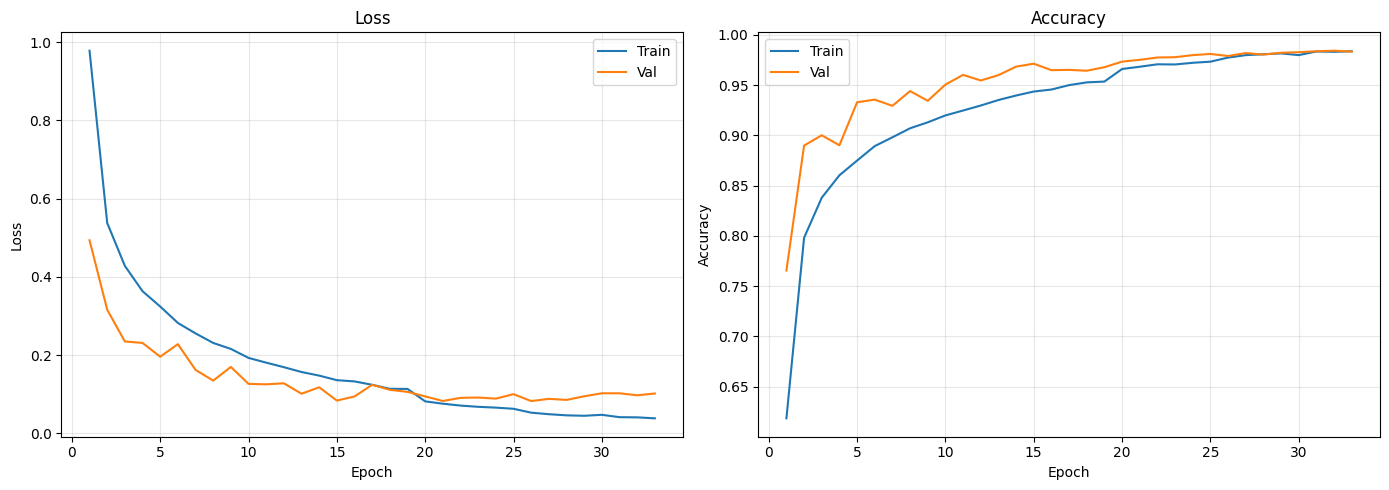

In [11]:
# ── 9. Training curves ────────────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train')
ax1.plot(epochs_ran, history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['train_acc'], label='Train')
ax2.plot(epochs_ran, history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'training_curves.png', dpi=150)
plt.show()

In [12]:
# ── 10. Load best model & evaluate on test set ────────────────────────────────
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f}, val_acc={checkpoint['val_acc']:.4f})")

test_preds, test_labels = predict_all(test_loader)

test_acc = (test_preds == test_labels).mean()
test_f1  = f1_score(test_labels, test_preds, average='macro')
print(f'\nTest accuracy : {test_acc:.4f}')
print(f'Test macro-F1 : {test_f1:.4f}')

Loaded best model from epoch 26 (val_loss=0.0823, val_acc=0.9789)

Test accuracy : 0.9809
Test macro-F1 : 0.9776


In [13]:
# ── 11. Per-class classification report ───────────────────────────────────────
print(classification_report(test_labels, test_preds,
                             target_names=CFG['label_names'], digits=4))

                      precision    recall  f1-score   support

  background_animals     0.9825    0.9749    0.9787      1154
background_wind_rain     0.9674    0.9816    0.9745       272
     threat_chainsaw     0.9804    0.9804    0.9804       510
          threat_dog     0.9196    0.9537    0.9364       216
      threat_gunshot     1.0000    1.0000    1.0000       480
        threat_human     0.9911    0.9876    0.9893       563
      threat_vehicle     0.9860    0.9815    0.9838       216

            accuracy                         0.9809      3411
           macro avg     0.9753    0.9799    0.9776      3411
        weighted avg     0.9811    0.9809    0.9810      3411



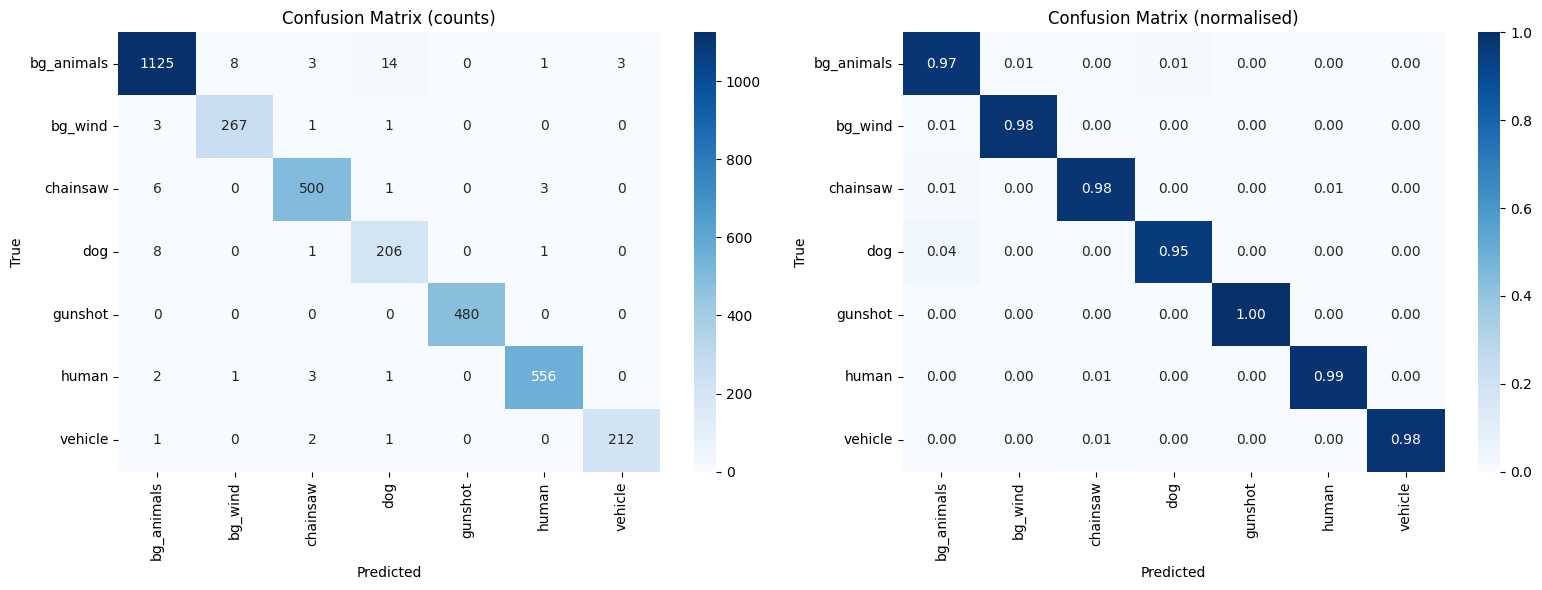

In [14]:
# ── 12. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short_names = ['bg_animals', 'bg_wind', 'chainsaw', 'dog', 'gunshot', 'human', 'vehicle']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=short_names, yticklabels=short_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'confusion_matrix.png', dpi=150)
plt.show()

In [15]:
# ── 13. Save results JSON ─────────────────────────────────────────────────────
results = {
    'model':        'CNN from scratch',
    'best_epoch':   int(checkpoint['epoch']),
    'val_loss':     float(checkpoint['val_loss']),
    'val_acc':      float(checkpoint['val_acc']),
    'test_acc':     float(test_acc),
    'test_macro_f1': float(test_f1),
    'per_class_f1': {
        name: float(f1_score(test_labels == i, test_preds == i, average='binary'))
        for i, name in enumerate(CFG['label_names'])
    },
    'n_params':     n_params,
    'history':      history,
}

results_path = CFG['output_dir'] / 'results.json'
results_path.write_text(json.dumps(results, indent=2))
print(f'Results saved → {results_path}')

print('\n=== Summary ===')
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {test_f1:.4f}")
print(f"Parameters    : {n_params:,}")
print(f"Best epoch    : {checkpoint['epoch']}")

Results saved → /kaggle/working/models/cnn/results.json

=== Summary ===
Test accuracy : 0.9809
Test macro-F1 : 0.9776
Parameters    : 1,206,439
Best epoch    : 26


In [ ]:
# ── 14. Export to ONNX (for Pi deployment via ONNX Runtime) ───────────────────
import torch.onnx

onnx_path = CFG['output_dir'] / 'alertreck_cnn.onnx'

model.eval()
dummy_input = torch.randn(1, 1, CFG['n_mels'], CFG['n_frames']).to(device)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['mel_spectrogram'],
    output_names=['class_logits'],
    dynamic_axes={
        'mel_spectrogram': {0: 'batch_size'},
        'class_logits':    {0: 'batch_size'},
    },
)
print(f'ONNX model saved → {onnx_path}')
print(f'Input  : (batch, 1, {CFG["n_mels"]}, {CFG["n_frames"]})')
print(f'Output : (batch, {CFG["n_classes"]})')

# save model config alongside for inference script
model_config = {
    'n_classes':   CFG['n_classes'],
    'n_mels':      CFG['n_mels'],
    'n_frames':    CFG['n_frames'],
    'label_names': CFG['label_names'],
    'test_acc':    float(test_acc),
    'test_macro_f1': float(test_f1),
    'best_epoch':  int(checkpoint['epoch']),
    'best_phase':  checkpoint.get('phase', 'unknown'),
}
config_path = CFG['output_dir'] / 'model_config_custom_cnn.json'
config_path.write_text(json.dumps(model_config, indent=2))
print(f'Model config    → {config_path}')